In [2]:
import os
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set pandas display options
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Enhanced seaborn styling for high-quality plots
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3
})

### loads `.env`
#### Setting up the `database connection`

In [3]:
load_dotenv()

pg_url = (
    f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
)

engine = create_engine(pg_url, pool_pre_ping=True)

with engine.begin() as conn:
    conn.execute(text("SET search_path TO mart, curated, public;"))

with engine.begin() as conn:
    print(conn.execute(text("SELECT now()")).scalar())

2025-12-04 22:04:54.231295-05:00


##### Build the high-risk provider dataset

In [4]:
import pandas as pd
from sqlalchemy import text

# Load provider-level features for train and test
df_prov_train = pd.read_sql("""
    SELECT *
    FROM mart.features_provider
""", con=engine)

print("Train provider features shape:", df_prov_train.shape)

# Test features
df_prov_test = pd.read_sql("""
    SELECT *
    FROM test.features_provider
""", con=engine)

print("Test provider features shape:", df_prov_test.shape)

# Load LR predictions for test providers
df_pred_lr = pd.read_sql("""
    SELECT *
    FROM test.provider_predictions_lr_final
""", con=engine)

print("Test LR predictions shape:", df_pred_lr.shape)

# Identify the provider ID column name
prov_id_col = "provider"

# Sanity check: provider id must exist in all tables
assert prov_id_col in df_prov_train.columns
assert prov_id_col in df_prov_test.columns
assert prov_id_col in df_pred_lr.columns

# Merge test features with LR predictions
df_prov_test_scored = df_prov_test.merge(
    df_pred_lr[[prov_id_col, "fraud_score_lr", "fraud_label_0_1_lr"]],
    on=prov_id_col,
    how="inner"
)

print("Test providers with scores shape:", df_prov_test_scored.shape)

# Filter:
# - Train: keep true frauds only (label_provider_fraud_1_0 = 1)
# - Test: keep high-risk by score (or label=1). We'll use score >= 0.8 as default.
fraud_col = "label_provider_fraud_1_0"

assert fraud_col in df_prov_train.columns

df_train_fraud = df_prov_train[df_prov_train[fraud_col] == 1].copy()
print("Train fraud providers:", len(df_train_fraud))

# High-risk test providers
highrisk_score_cutoff = 0.8
df_test_highrisk = df_prov_test_scored[
    df_prov_test_scored["fraud_score_lr"] >= highrisk_score_cutoff
].copy()

print("Test high-risk providers (score >= 0.8):", len(df_test_highrisk))

# Add a 'source' flag
df_train_fraud["source"] = "train_fraud"
df_test_highrisk["source"] = "test_highrisk"

# Align columns (keep only shared feature columns + IDs + flags)
common_cols = sorted(
    set(df_train_fraud.columns).intersection(df_test_highrisk.columns)
)

df_prov_fraud_universe = pd.concat(
    [
        df_train_fraud[common_cols],
        df_test_highrisk[common_cols]
    ],
    ignore_index=True
)

print("Provider fraud universe shape:", df_prov_fraud_universe.shape)
print("Source breakdown:")
print(df_prov_fraud_universe["source"].value_counts())

Train provider features shape: (5410, 31)
Test provider features shape: (1353, 30)
Test LR predictions shape: (1353, 3)
Test providers with scores shape: (1353, 32)
Train fraud providers: 506
Test high-risk providers (score >= 0.8): 64
Provider fraud universe shape: (570, 31)
Source breakdown:
source
train_fraud      506
test_highrisk     64
Name: count, dtype: int64


##### 7.2 Choose features & standardize (provider level)

In [5]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print(df_prov_fraud_universe.columns)

# Choose a feature subset for clustering
prov_feat_cols = [
    "reimb_365d",
    "reimb_90d",
    "reimb_30d",
    "claims_365d",
    "claims_90d",
    "claims_30d",
    "unique_benes_365d",
    "unique_benes_90d",
    "unique_benes_30d",
    "dx_distinct_30d",
    "px_distinct_30d",
    "ip_claims_365",
    "op_claims_365",
    "ip_avg_z_reimb_365",
    "ip_max_z_reimb_365",
    "ip_avg_z_los_365",
    "ip_max_z_los_365",
    "op_avg_z_reimb_365",
    "op_max_z_reimb_365",
    "dup_exact_claims",
    "dup_near_total",
    "overcharge_z_claims",
    "overcharge_iqr_claims",
    "upcoding_ip_claims",
    "upcoding_op_claims",
    "deductible_share_30d",
]

# Keep only those that actually exist
prov_feat_cols = [
    c for c in prov_feat_cols if c in df_prov_fraud_universe.columns]
print("Using", len(prov_feat_cols), "features for provider clustering:")
print(prov_feat_cols)

X_prov = df_prov_fraud_universe[prov_feat_cols].copy()

# Impute & scale
imp_prov = SimpleImputer(strategy="median")
X_prov_imp = imp_prov.fit_transform(X_prov)

scaler_prov = StandardScaler()
X_prov_scaled = scaler_prov.fit_transform(X_prov_imp)

print("X_prov_scaled shape:", X_prov_scaled.shape)

Index(['avg_reimb_day_30d', 'avg_reimb_per_claim', 'claims_30d', 'claims_365d',
       'claims_90d', 'claims_total', 'deductible_share_30d',
       'dup_exact_claims', 'dup_near_total', 'dx_distinct_30d',
       'ip_avg_z_los_365', 'ip_avg_z_reimb_365', 'ip_claims_365',
       'ip_max_z_los_365', 'ip_max_z_reimb_365', 'op_avg_z_reimb_365',
       'op_claims_365', 'op_max_z_reimb_365', 'overcharge_iqr_claims',
       'overcharge_z_claims', 'provider', 'px_distinct_30d', 'reimb_30d',
       'reimb_365d', 'reimb_90d', 'source', 'unique_benes_30d',
       'unique_benes_365d', 'unique_benes_90d', 'upcoding_ip_claims',
       'upcoding_op_claims'],
      dtype='object')
Using 26 features for provider clustering:
['reimb_365d', 'reimb_90d', 'reimb_30d', 'claims_365d', 'claims_90d', 'claims_30d', 'unique_benes_365d', 'unique_benes_90d', 'unique_benes_30d', 'dx_distinct_30d', 'px_distinct_30d', 'ip_claims_365', 'op_claims_365', 'ip_avg_z_reimb_365', 'ip_max_z_reimb_365', 'ip_avg_z_los_365', 'ip

##### 7.3 HDBSCAN clustering for providers + PCA visualization

##### 7.3.1 Run HDBSCAN on provider features

Cluster label counts (including noise = -1):
cluster_id
-1    334
 0     10
 1     36
 2     10
 3    180
Name: count, dtype: int64
Provider PCA variance explained (2D): 0.5897974580071934


c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


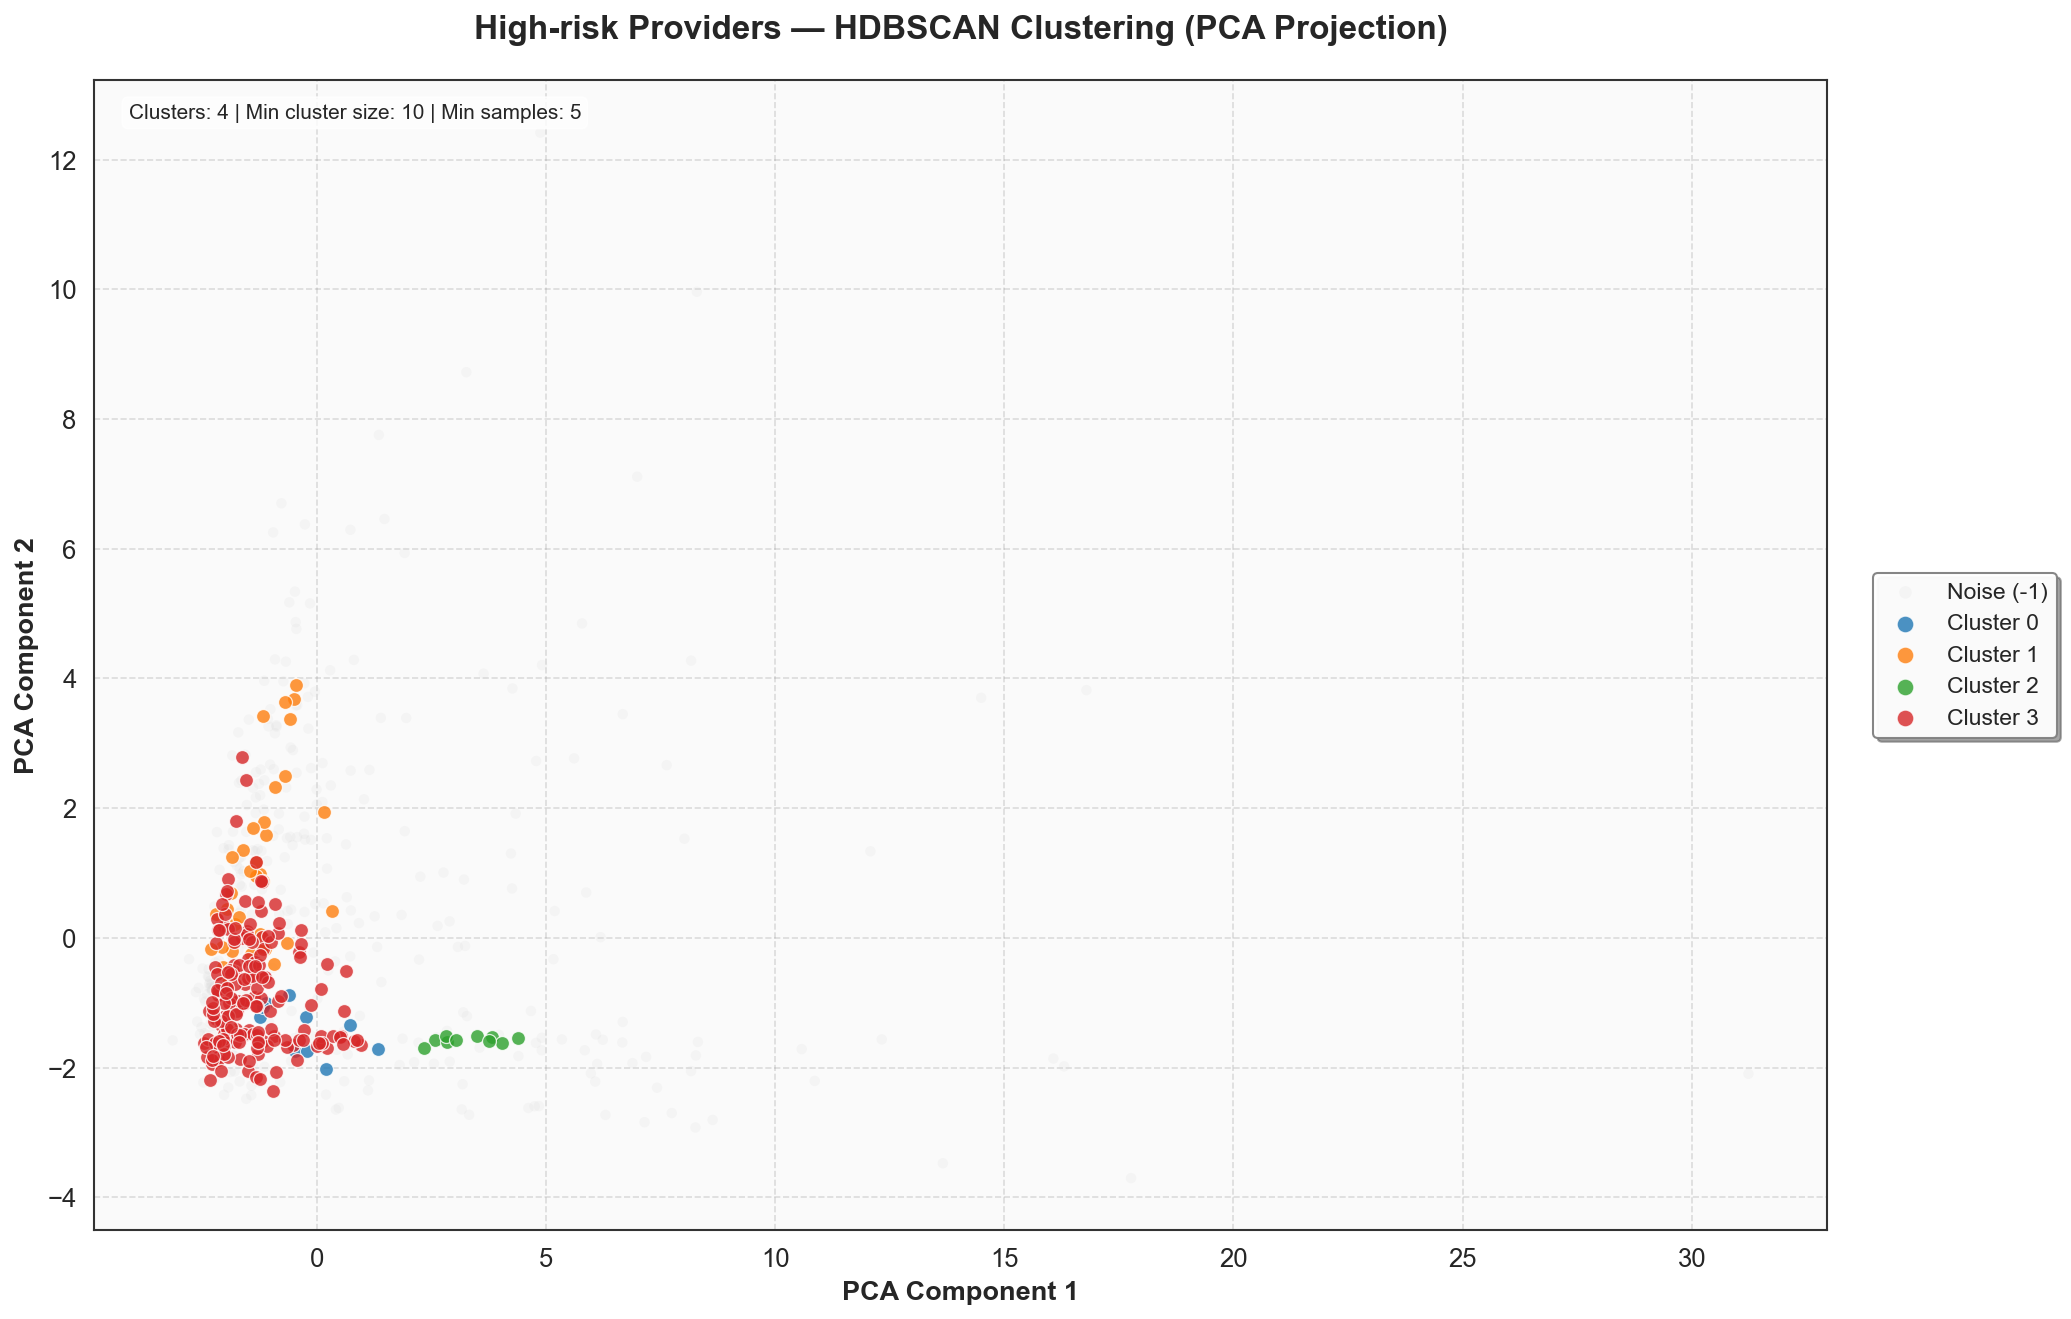

In [6]:
import hdbscan
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# HDBSCAN with more permissive parameters
min_cluster_size = 10
min_samples = 5

clusterer_prov = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
    cluster_selection_method="leaf",
    prediction_data=True
)

prov_labels = clusterer_prov.fit_predict(X_prov_scaled)
df_prov_fraud_universe["cluster_id"] = prov_labels

print("Cluster label counts (including noise = -1):")
print(df_prov_fraud_universe["cluster_id"].value_counts().sort_index())

# PCA
pca_prov = PCA(n_components=2, random_state=42)
X_prov_pca = pca_prov.fit_transform(X_prov_scaled)

df_prov_fraud_universe["pca1"] = X_prov_pca[:, 0]
df_prov_fraud_universe["pca2"] = X_prov_pca[:, 1]

print("Provider PCA variance explained (2D):",
      pca_prov.explained_variance_ratio_.sum())

# High-quality plot with seaborn styling
sns.set_context("paper", font_scale=1.4)
sns.set_style("whitegrid", {
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'axes.edgecolor': '.2',
    'axes.linewidth': 1.2
})

fig, ax = plt.subplots(figsize=(14, 9), dpi=150)

# Plot noise points first (subtle background)
noise_mask = df_prov_fraud_universe["cluster_id"] == -1
if noise_mask.any():
    ax.scatter(
        df_prov_fraud_universe.loc[noise_mask, "pca1"],
        df_prov_fraud_universe.loc[noise_mask, "pca2"],
        s=25, alpha=0.15, color='#d3d3d3', 
        label="Noise (-1)", edgecolors='none', rasterized=True
    )

# Plot clusters with professional color palette
cluster_ids = sorted([c for c in df_prov_fraud_universe["cluster_id"].unique() if c != -1])
n_clusters = len(cluster_ids)

if n_clusters > 0:
    if n_clusters <= 10:
        palette = sns.color_palette("tab10", n_clusters)
    else:
        palette = sns.color_palette("husl", n_clusters)
    
    for i, cl in enumerate(cluster_ids):
        mask = df_prov_fraud_universe["cluster_id"] == cl
        ax.scatter(
            df_prov_fraud_universe.loc[mask, "pca1"],
            df_prov_fraud_universe.loc[mask, "pca2"],
            s=45, alpha=0.8, color=palette[i],
            label=f"Cluster {cl}", 
            edgecolors='white', linewidth=0.6
        )

# Professional styling
ax.set_title(f"High-risk Providers — HDBSCAN Clustering (PCA Projection)", 
             fontsize=16, fontweight='bold', pad=20, family='sans-serif')
ax.set_xlabel("PCA Component 1", fontsize=13, fontweight='bold', family='sans-serif')
ax.set_ylabel("PCA Component 2", fontsize=13, fontweight='bold', family='sans-serif')

# Enhanced grid and background
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
ax.set_facecolor('#fafafa')

# Professional legend
if n_clusters > 0 or noise_mask.any():
    ncol = 1 if n_clusters <= 8 else 2
    legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                      frameon=True, shadow=True, fancybox=True,
                      fontsize=11, ncol=ncol, markerscale=1.2)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor('gray')
    legend.get_frame().set_linewidth(1)

# Add cluster statistics as text
cluster_stats = f"Clusters: {n_clusters} | Min cluster size: {min_cluster_size} | Min samples: {min_samples}"
ax.text(0.02, 0.98, cluster_stats, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("high_risk_providers_hdbscan.png", bbox_inches="tight", dpi=300, facecolor='white')
plt.show()

# Reset style for subsequent plots
sns.set_style("whitegrid")

##### 7.4 – Build provider cluster cards (summary per cluster)

In [7]:
import numpy as np
import pandas as pd

# Summarize only the real clusters (id >= 0)
valid_clusters = sorted(
    [c for c in df_prov_fraud_universe["cluster_id"].unique() if c >= 0])
print("Provider clusters (excluding noise):", valid_clusters)

# Pick a subset of features that are most interpretable for the cards
summary_feats = [
    "reimb_365d",
    "claims_365d",
    "claims_30d",
    "unique_benes_365d",
    "ip_claims_365",
    "op_claims_365",
    "ip_avg_z_reimb_365",
    "ip_max_z_reimb_365",
    "ip_avg_z_los_365",
    "ip_max_z_los_365",
    "op_avg_z_reimb_365",
    "op_max_z_reimb_365",
    "dup_exact_claims",
    "dup_near_total",
    "upcoding_ip_claims",
    "upcoding_op_claims",
    "overcharge_z_claims",
    "overcharge_iqr_claims",
    "deductible_share_30d",
    "avg_reimb_per_claim",
]

# Make sure they all exist
missing_summary = [
    c for c in summary_feats if c not in df_prov_fraud_universe.columns]
print("Missing summary features:", missing_summary)

# Remove missing features
summary_feats = [
    c for c in summary_feats if c in df_prov_fraud_universe.columns]

rows = []

for cl in valid_clusters:
    sub = df_prov_fraud_universe[df_prov_fraud_universe["cluster_id"] == cl]
    n = len(sub)

    # Source mix
    source_counts = sub["source"].value_counts().to_dict()
    train_frac = source_counts.get("train_fraud", 0) / n
    test_frac = source_counts.get("test_highrisk", 0) / n

    # Basic scale: total/median reimb & claims
    total_reimb = float(sub["reimb_365d"].sum()
                        ) if "reimb_365d" in sub else np.nan
    median_reimb = float(sub["reimb_365d"].median()
                         ) if "reimb_365d" in sub else np.nan
    median_claims_365 = float(
        sub["claims_365d"].median()) if "claims_365d" in sub else np.nan

    row = {
        "cluster": cl,
        "n_providers": n,
        "frac_train_fraud": round(train_frac, 3),
        "frac_test_highrisk": round(test_frac, 3),
        "total_reimb_365d": round(total_reimb, 2),
        "median_reimb_365d": round(median_reimb, 2),
        "median_claims_365d": round(median_claims_365, 2),
    }

    # Add medians of the summary features
    for feat in summary_feats:
        row[f"med_{feat}"] = round(float(sub[feat].median()), 3)

    rows.append(row)

cluster_cards = pd.DataFrame(rows).sort_values("n_providers", ascending=False)
print("Provider cluster cards (summary):")
pd.set_option("display.max_columns", 50)
print(cluster_cards.to_string(index=False))

Provider clusters (excluding noise): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Missing summary features: []
Provider cluster cards (summary):
 cluster  n_providers  frac_train_fraud  frac_test_highrisk  total_reimb_365d  median_reimb_365d  median_claims_365d  med_reimb_365d  med_claims_365d  med_claims_30d  med_unique_benes_365d  med_ip_claims_365  med_op_claims_365  med_ip_avg_z_reimb_365  med_ip_max_z_reimb_365  med_ip_avg_z_los_365  med_ip_max_z_los_365  med_op_avg_z_reimb_365  med_op_max_z_reimb_365  med_dup_exact_claims  med_dup_near_total  med_upcoding_ip_claims  med_upcoding_op_claims  med_overcharge_z_claims  med_overcharge_iqr_claims  med_deductible_share_30d  med_avg_reimb_per_claim
       3          180              1.00                0.00     47,153,160.00         210,265.00              108.50      210,265.00           108.50           34.00                  83.50              21.00             100.50                    0.00                    2.75             

c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


#### 7.6.A – Save provider fraud clusters to the DB

In [8]:
from sqlalchemy import text

# Decide what to store
cols_to_keep = [
    "provider",
    "source",
    "cluster_id",
    "reimb_365d",
    "claims_365d",
    "claims_30d",
    "unique_benes_365d",
    "ip_claims_365",
    "op_claims_365",
    "ip_avg_z_reimb_365",
    "ip_max_z_reimb_365",
    "ip_avg_z_los_365",
    "ip_max_z_los_365",
    "op_avg_z_reimb_365",
    "op_max_z_reimb_365",
    "dup_exact_claims",
    "dup_near_total",
    "upcoding_ip_claims",
    "upcoding_op_claims",
    "overcharge_z_claims",
    "overcharge_iqr_claims",
    "deductible_share_30d",
    "avg_reimb_per_claim",
    "pca1",
    "pca2",
]

# Make sure all exist before writing
cols_to_keep = [c for c in cols_to_keep if c in df_prov_fraud_universe.columns]

df_provider_clusters = df_prov_fraud_universe[cols_to_keep].copy()

print("provider_clusters shape:", df_provider_clusters.shape)
print(df_provider_clusters.head())

# Write to mart.provider_fraud_clusters
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS mart.provider_fraud_clusters"))
    df_provider_clusters.to_sql(
        "provider_fraud_clusters",
        con=conn,
        schema="mart",
        index=False,
        method="multi"
    )

print("Wrote mart.provider_fraud_clusters")

# QA check with SQL
check_df = pd.read_sql("""
    SELECT cluster_id, COUNT(*) AS n_providers
    FROM mart.provider_fraud_clusters
    GROUP BY cluster_id
    ORDER BY cluster_id
""", con=engine)

print("Cluster counts from DB:")
print(check_df)

provider_clusters shape: (570, 25)
   provider       source  cluster_id  reimb_365d  claims_365d  claims_30d  \
0  PRV51003  train_fraud           1  605,670.00       132.00       35.00   
1  PRV51021  train_fraud          -1  348,830.00       257.00       41.00   
2  PRV51037  train_fraud           3  342,230.00       454.00       42.00   
3  PRV51052  train_fraud          -1   30,800.00        46.00       34.00   
4  PRV51059  train_fraud          -1  421,060.00        96.00       33.00   

   unique_benes_365d  ip_claims_365  op_claims_365  ip_avg_z_reimb_365  \
0                117          61.00          70.00               -0.01   
1                207          28.00         223.00                0.02   
2                206          21.00         423.00               -0.00   
3                 37           2.00          44.00               -0.34   
4                 82          25.00          69.00                0.54   

   ip_max_z_reimb_365  ip_avg_z_los_365  ip_max_z_los_365